# 00 — Exploratory Data Analysis

This notebook provides an initial overview of the SVH dataset.  
The goal is to understand the structure, distributions, and missing data  
before moving into the main analyses (MyChart app usage, patient distance).

In [ ]:
#set up
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import *
from src.data_loader import (load_patients, load_encounters,
                              load_diagnosis, load_departments,
                              load_tiger, load_social_det)
from src.plot_utils import set_style, save_fig

set_style()
print("Setup complete")

Setup complete


## 1. Load Data
Load all raw CSV files. Encounters are sampled at 5% during development  
to keep runtimes manageable — switch `sample_frac` to `1.0` for final runs.

In [ ]:
#Load data
pat  = load_patients()
diag = load_diagnosis()
dept = load_departments()
tiger = load_tiger()

# Start with 5% sample of encounters — switch to 1.0 for final run
enc = load_encounters(
    sample_frac=0.05,
    cols=["EncounterKey", "PatientDurableKey", "PrimaryDiagnosisKey",
          "DepartmentKey", "Date", "IsEdVisit", "IsHospitalAdmission"]
)

print(f"Patients:   {len(pat):,}")
print(f"Encounters (5% sample): {len(enc):,}")
print(f"Diagnosis:  {len(diag):,}")
print(f"Departments:{len(dept):,}")

Patients:   947,685
Encounters (5% sample): 383,790
Diagnosis:  1,531,262
Departments:11,597


## 2. MyChart Status
MyChart is SVH's patient portal app. Understanding its adoption rate  
is the foundation of our main analysis.

In [6]:
#MyChartStatus distribution
print("=== MyChartStatus distribution ===")
status = pat["MyChartStatus"].value_counts(dropna=False)
print(status)
print(f"\nActivated rate: {status.get('Activated', 0) / len(pat):.1%}")

=== MyChartStatus distribution ===
MyChartStatus
*Unspecified                               392762
Activated                                  274082
Pending Activation                         177728
Inactivated                                 65377
Non Standard MyChart Status                 35411
Patient Declined                             2161
Activation Code Generated, but Disabled       164
Name: count, dtype: int64

Activated rate: 28.9%


Saved: mychart_status_distribution


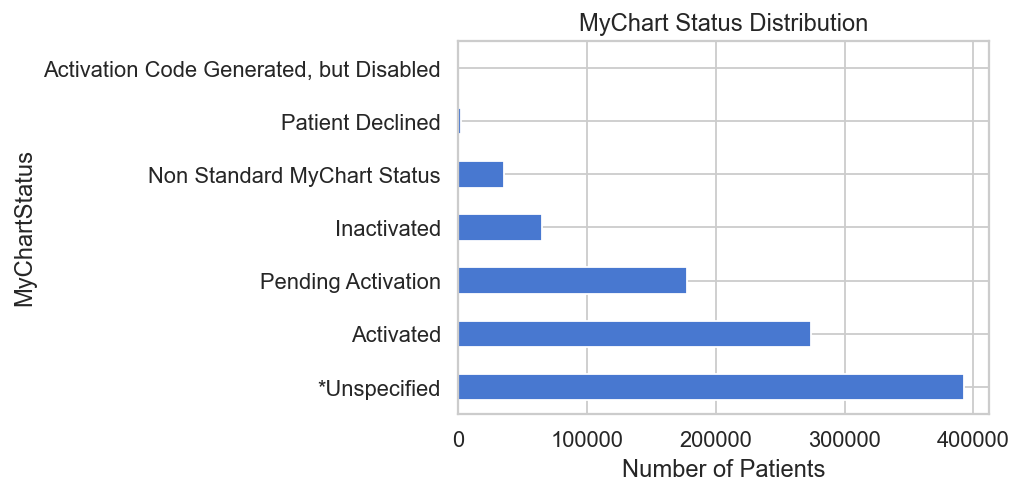

In [7]:
#Plot MyChartStatus
fig, ax = plt.subplots(figsize=(8, 4))
status.plot(kind="barh", ax=ax)
ax.set_title("MyChart Status Distribution")
ax.set_xlabel("Number of Patients")
plt.tight_layout()
save_fig(fig, "mychart_status_distribution")
plt.show()

## 3. Define App User Groups
We classify patients as **app users** (Activated) vs **non-app users** (all other statuses).  
This binary variable is used throughout the subsequent analyses.

In [8]:
#Define app user groups
# Activated = engaged; everything else = not engaged
pat["app_user"] = pat["MyChartStatus"] == "Activated"

print(pat["app_user"].value_counts())
print(f"\nApp users:     {pat['app_user'].sum():,}")
print(f"Non-app users: {(~pat['app_user']).sum():,}")

app_user
False    673603
True     274082
Name: count, dtype: int64

App users:     274,082
Non-app users: 673,603


## 4. Demographic Breakdown
Check whether app users differ systematically from non-app users  
in age, sex, and smoking status — these will be control variables later.

In [9]:
#Demographics by app user group
print("=== Age distribution by app status ===")
print(pat.groupby("app_user")["PatientBirthYearBin"].value_counts(normalize=True).unstack())

print("\n=== Sex by app status ===")
print(pat.groupby("app_user")["SexAssignedAtBirth"].value_counts(normalize=True).unstack())

print("\n=== Smoking status by app status ===")
print(pat.groupby("app_user")["SmokingStatus"].value_counts(normalize=True).unstack())

=== Age distribution by app status ===
PatientBirthYearBin    1845.0    1850.0    1855.0    1860.0    1880.0  \
app_user                                                                
False                0.000001  0.001179  0.000004  0.000001  0.000009   
True                      NaN  0.000004       NaN       NaN       NaN   

PatientBirthYearBin    1885.0    1890.0    1895.0    1900.0    1905.0  ...  \
app_user                                                               ...   
False                0.000025  0.000546  0.000845  0.009470  0.006463  ...   
True                      NaN       NaN       NaN  0.000026       NaN  ...   

PatientBirthYearBin    1980.0    1985.0    1990.0    1995.0    2000.0  \
app_user                                                                
False                0.071879  0.073912  0.074337  0.069349  0.059907   
True                 0.074063  0.074749  0.075651  0.076308  0.064977   

PatientBirthYearBin    2005.0    2010.0    2015.0    2020.0   

## 5. Missing Data
Identify missing or unspecified values. Note that `*Unspecified` means  
the field was asked but not answered; blank means it was never recorded.

In [10]:
#Missing values check
print("=== Missing values in patients ===")
print(pat.isnull().sum()[pat.isnull().sum() > 0])

print("\n=== Missing values in encounters ===")
print(enc.isnull().sum()[enc.isnull().sum() > 0])

=== Missing values in patients ===
FirstRace              365398
PatientBirthYearBin      1725
dtype: int64

=== Missing values in encounters ===
Series([], dtype: int64)


## 6. Encounter Overview
High-level look at encounter volume, ED visit rates, and how many  
encounters each patient has in the sample.

In [11]:
#Encounter types overview
print("=== Patients with encounters (in sample) ===")
enc_patients = enc["PatientDurableKey"].nunique()
print(f"{enc_patients:,} unique patients in 5% encounter sample")

print("\n=== ED visit rate overall ===")
print(f"{enc['IsEdVisit'].mean():.1%} of encounters are ED visits")

print("\n=== Hospital admission rate overall ===")
print(f"{enc['IsHospitalAdmission'].mean():.1%} of encounters are hospital admissions")

=== Patients with encounters (in sample) ===
153,225 unique patients in 5% encounter sample

=== ED visit rate overall ===
3.4% of encounters are ED visits

=== Hospital admission rate overall ===
1.3% of encounters are hospital admissions


Saved: encounters_per_patient


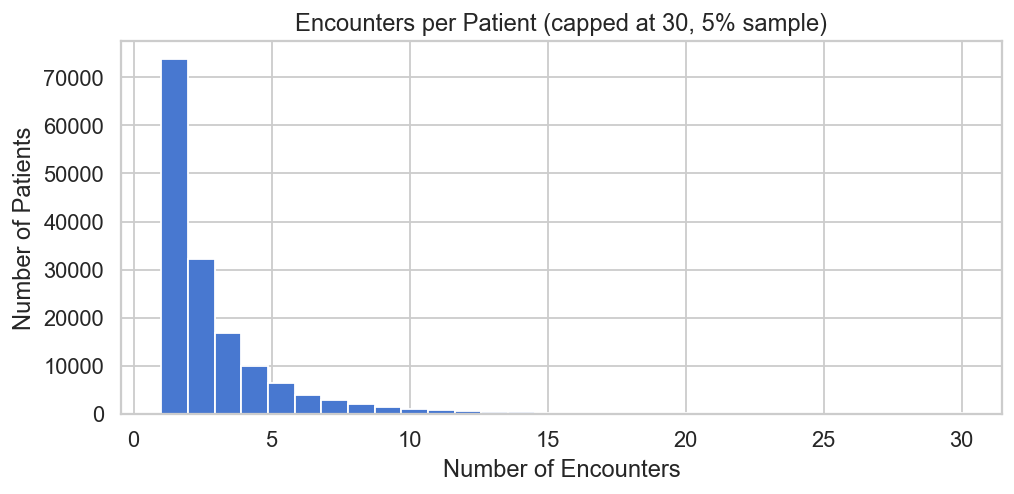

count    153225.000000
mean          2.504748
std           2.529186
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          58.000000
Name: EncounterKey, dtype: float64


In [12]:
#Encounters per patient distribution
enc_per_patient = enc.groupby("PatientDurableKey")["EncounterKey"].count()

fig, ax = plt.subplots(figsize=(8, 4))
enc_per_patient.clip(upper=30).hist(bins=30, ax=ax)
ax.set_title("Encounters per Patient (capped at 30, 5% sample)")
ax.set_xlabel("Number of Encounters")
ax.set_ylabel("Number of Patients")
plt.tight_layout()
save_fig(fig, "encounters_per_patient")
plt.show()

print(enc_per_patient.describe())

## 7. Social Determinants — Transportation
The Transportation Needs domain asks whether lack of transport  
affected medical appointments. This serves as a qualitative proxy  
for distance burden in our analysis.

In [13]:
#Social determinants: transportation questions
# Load only transportation domain — directly relevant to our distance analysis
social = load_social_det(cols=["PatientDurableKey", "EncounterKey",
                                "Domain", "DisplayName", "AnswerText"])

transport = social[social["Domain"] == "Transportation Needs"]
print(f"Transportation responses: {len(transport):,}")
print("\nQuestion breakdown:")
print(transport["DisplayName"].value_counts())

print("\nAnswer distribution:")
print(transport["AnswerText"].value_counts(dropna=False).head(10))

Transportation responses: 164,273

Question breakdown:
DisplayName
In the past 12 months, has lack of transportation kept you from medical appointments or from getting medications?                  82166
In the past 12 months, has lack of transportation kept you from meetings, work, or from getting things needed for daily living?    82107
Name: count, dtype: int64

Answer distribution:
AnswerText
No                          152019
Yes                           6806
Patient declined              3336
Patient unable to answer      2112
Name: count, dtype: int64


## 8. Geographic Coverage
Check how many patients can be geocoded via the TIGER census block data.  
Patients with `*Unspecified` block codes cannot be assigned a distance  
and will be excluded from the distance supplementary analysis.

In [14]:
#Tiger census coverage check
print("=== Tiger census codes ===")
print(tiger.head())
print(f"\nTotal census blocks: {len(tiger):,}")

# Check how many patients can be geocoded
matched = pat["CensusBlockGroupFipsCode"].isin(tiger["GEOID"])
print(f"\nPatients with geocodeable block: {matched.sum():,} "
      f"({matched.mean():.1%})")
print(f"Patients with '*Unspecified':    {(pat['CensusBlockGroupFipsCode'] == '*Unspecified').sum():,}")

=== Tiger census codes ===
          GEOID  PopulationValue    CENTLAT    CENTLON
0  200019526001           1791.0  37.873751 -95.203664
1  200019527001           1052.0  37.987188 -95.380907
2  200019527002            957.0  37.907415 -95.344626
3  200019528001           1179.0  37.942439 -95.420724
4  200019528002           1541.0  37.947521 -95.381379

Total census blocks: 2,463

Patients with geocodeable block: 335,757 (35.4%)
Patients with '*Unspecified':    611,171


## 9. Summary

In [16]:
#Summary & next steps
print("=" * 50)
print("EDA Summary")
print("=" * 50)
print(f"Total patients:          {len(pat):,}")
print(f"App activated:           {pat['app_user'].sum():,} ({pat['app_user'].mean():.1%})")
print(f"Geocodeable patients:    {matched.sum():,} ({matched.mean():.1%})")
print(f"Encounter sample (5%):   {len(enc):,} rows")
print(f"ED visit rate:           {enc['IsEdVisit'].mean():.1%}")
print(f"Transport responses:     {len(transport):,}")
print("\nNext: run 01_mychart.ipynb for main analysis")

EDA Summary
Total patients:          947,685
App activated:           274,082 (28.9%)
Geocodeable patients:    335,757 (35.4%)
Encounter sample (5%):   383,790 rows
ED visit rate:           3.4%
Transport responses:     164,273

Next: run 01_mychart.ipynb for main analysis
